In [ ]:
### Remote Sensing Forest Change: Detecting Forest Conversion and its Biogeophysical Climate Effects and Ecological Effects in Bavaria
### Code for the Master's Thesis by Julia Jamula

## Time Series of CORINE Forest Classes

In [3]:
import ee
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

PROJECT_NAME='xxx'
ee.Initialize(project=PROJECT_NAME)

ASSET="xxx" # insert path
bayern = ee.FeatureCollection(ASSET)

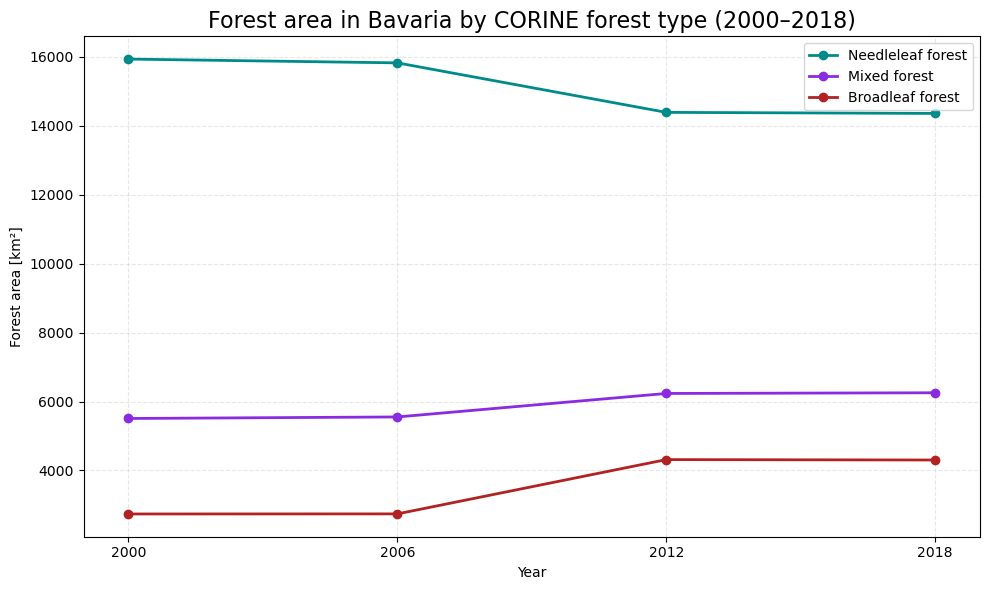

In [8]:
### CORINE Forest Type Time Series


years = [2000, 2006, 2012, 2018]

def corine_forest_area(year):
    img = ee.Image(f"COPERNICUS/CORINE/V20/100m/{year}") \
        .select("landcover") \
        .clip(bayern)

    needle = img.eq(312)
    broad  = img.eq(311)
    mixed  = img.eq(313)

    def area(mask):
        return (
            mask.multiply(ee.Image.pixelArea())
            .reduceRegion(
                reducer=ee.Reducer.sum(),
                geometry=bayern,
                scale=100,
                maxPixels=1e13
            )
            .values()
            .get(0)
        )

    return {
        "year": year,
        "needleleaf": ee.Number(area(needle)).divide(1e6),
        "broadleaf":  ee.Number(area(broad)).divide(1e6),
        "mixed":      ee.Number(area(mixed)).divide(1e6),
    }


areas = []

for y in years:
    res = corine_forest_area(y)
    areas.append({
        "year": y,
        "needleleaf": res["needleleaf"].getInfo(),
        "broadleaf": res["broadleaf"].getInfo(),
        "mixed": res["mixed"].getInfo()
    })

df = pd.DataFrame(areas)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df["year"], df["needleleaf"],
    marker="o", color="darkcyan",
    linewidth=2, label="Needleleaf forest"
)

ax.plot(
    df["year"], df["mixed"],
    marker="o", color="blueviolet",
    linewidth=2, label="Mixed forest"
)

ax.plot(
    df["year"], df["broadleaf"],
    marker="o", color="firebrick",
    linewidth=2, label="Broadleaf forest"
)



# X-Axis
ax.set_xticks(years)                         # only 2000, 2006, 2012, 2018
ax.set_xlim(1999, 2019)


# Grid
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.3)
ax.grid(True, which="minor", axis="x", linestyle="--", alpha=0.3)

ax.set_xlabel("Year")
ax.set_ylabel("Forest area [km²]")
ax.set_title("Forest area in Bavaria by CORINE forest type (2000–2018)", fontsize=16)
ax.legend()

plt.tight_layout()
plt.show()
plt.close()
